In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import lightkurve as lk


/Users/azib/micromamba/envs/exocomet/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/azib/.lightkurve/cache. Please move all the files in the legacy directory /Users/azib/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


---

In [2]:
data = pd.read_csv('../outputs_k2/k2-median-cometcurve2.txt',sep=' ',header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,/storage/astro2/phrdhx/k2/everest/c05/hlsp_eve...,EPIC,211916580,-7.20047,-7.20068,2377.16127,-3.0,-3.0,-3.0,-3.0,...,3453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
1,/storage/astro2/phrdhx/k2/everest/c05/hlsp_eve...,EPIC,211828066,-27.76620,-23.63156,2361.44915,-3.0,-3.0,-3.0,-3.0,...,2684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
2,/storage/astro2/phrdhx/k2/everest/c16/hlsp_eve...,EPIC,211401664,-31.83831,-22.13078,3281.73809,-3.0,-3.0,-3.0,-3.0,...,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
3,/storage/astro2/phrdhx/k2/everest/c16/hlsp_eve...,EPIC,212214571,-1.82963,-1.47503,3281.73840,-3.0,-3.0,-3.0,-3.0,...,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
4,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220485020,-57.41717,-48.58341,2572.73743,-3.0,-3.0,-3.0,-3.0,...,669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted


In [3]:
data2 = pd.read_csv('../outputs_k2/k2-median-skewness.txt',sep=' ',header=None)

In [4]:
columns = [
        "path",
        "Catalogue",
        "EPIC ID",
        "signal",
        "snr",
        "time",
        "asym_score",
        "amplitude",
        "width",
        "skewness",
        "skewness_err",
        "duration",
        "depth",
        "peak_lspower",
        "mstat",
        "m",
        "n",
        "chisq_gauss",
        "chisq_skew",
        "rchisq_gauss",
        "rchisq_skew",
        "rmse_gauss",
        "rmse_skew",
        "mae_gauss",
        "mae_skew",
        "transit_prob"
    ]

In [5]:
data.columns = columns
data2.columns = columns

In [31]:
data.columns = columns
len(data)

372850

In [32]:
data = data[data.transit_prob == 'maybeTransit']
len(data)

129253

In [33]:
data = data[(abs(data.snr) > 5) & (data.duration > 0.4) & (abs(data.depth) < 0.01)]
len(data)

1989

In [34]:
data['campaign'] = pd.to_numeric(
    data['path'].str.extract(r'/c(\d{1,3})/')[0],
    errors='coerce'
)

download complete


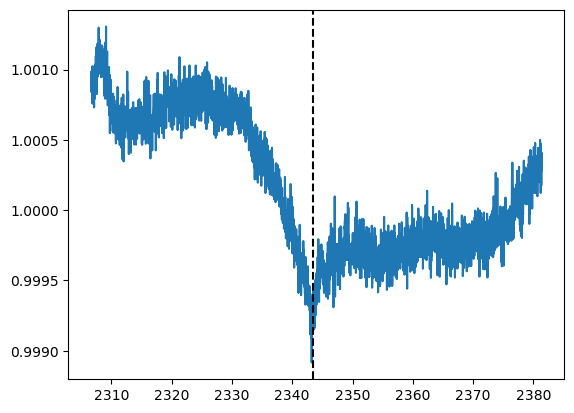

download complete


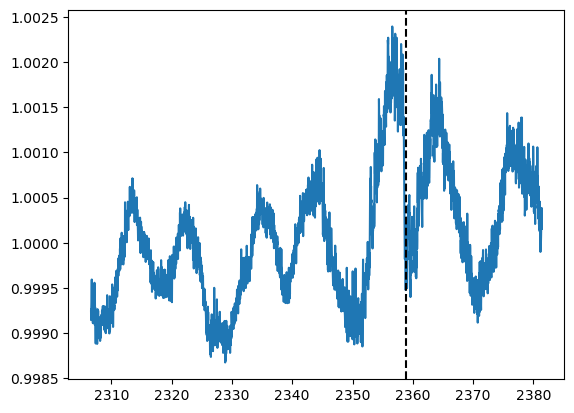

download complete


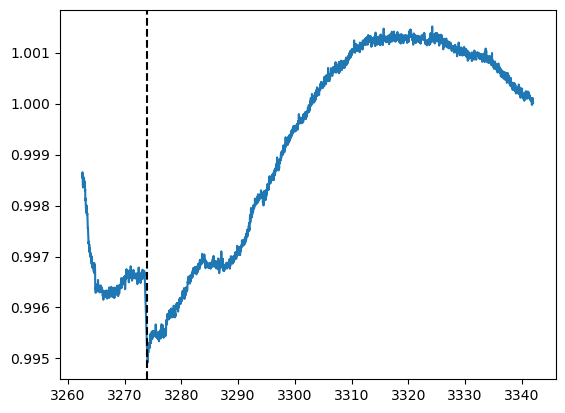

download complete


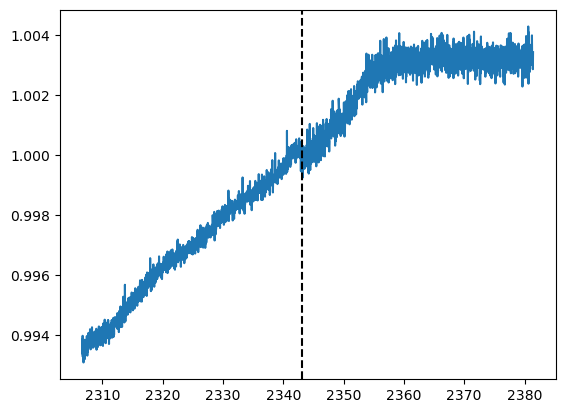

download complete


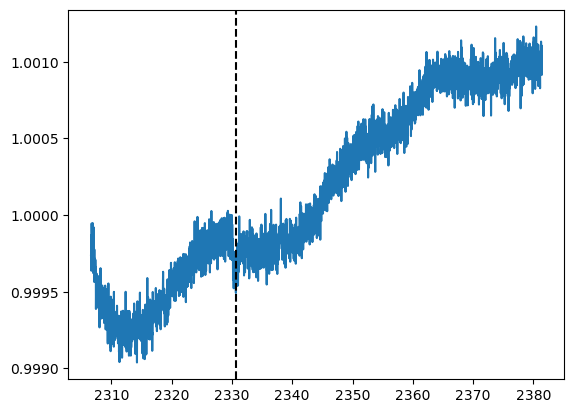

download complete


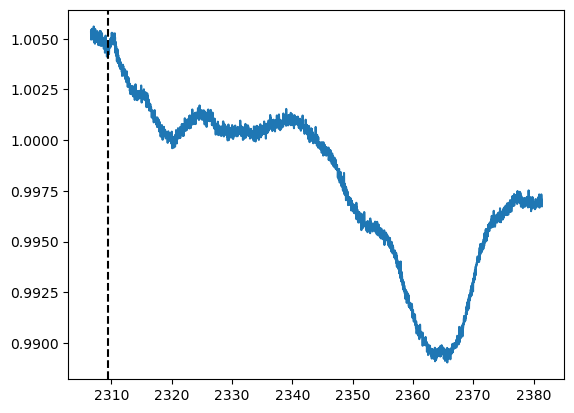

download complete


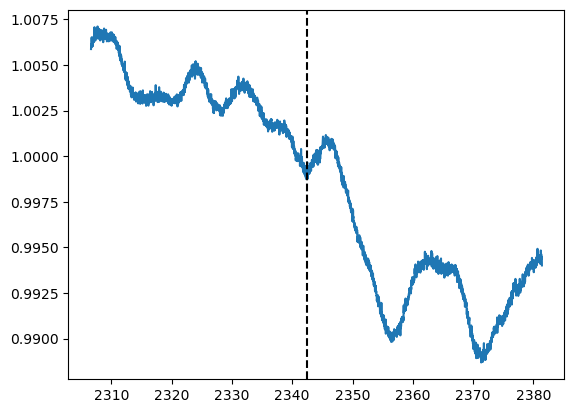

download complete


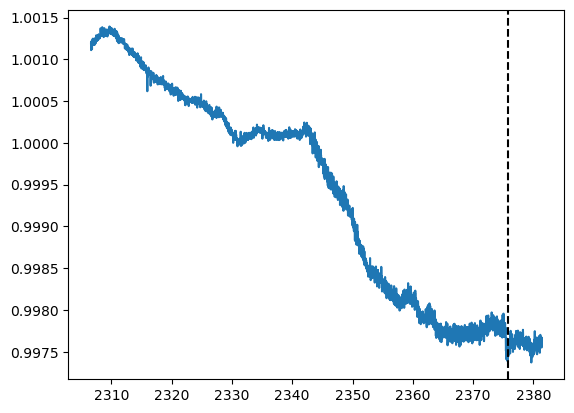

download complete


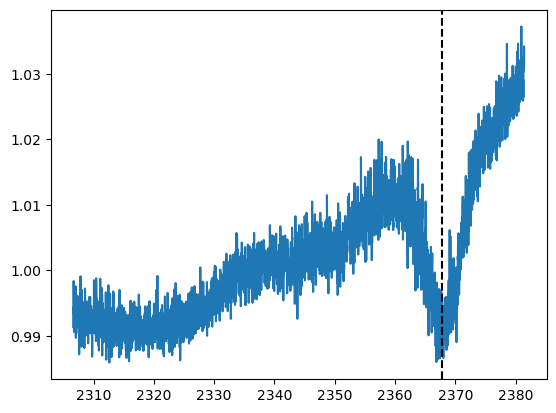

LightkurveError: Not recognized as a supported data product:
/Users/azib/.lightkurve/cache/mastDownload/HLSP/hlsp_everest_k2_llc_211741399-c05_kepler_v2.0_lc/hlsp_everest_k2_llc_211741399-c05_kepler_v2.0_lc.fits
This file may be corrupt due to an interrupted download. Please remove it from your disk and try again.

In [35]:
for i, row in data.iterrows():
    epic = row['EPIC ID']
    campaign = row['campaign']
    time = row['time']

    lc = lk.search_lightcurve(f'EPIC {epic}', mission='K2',author='EVEREST',campaign=campaign).download()
    lc = lc[lc.quality == 0]
    print("download complete")
    plt.plot(lc['time'].value,lc['flux'].value/np.nanmedian(lc['flux'].value))
    plt.axvline(time,linestyle='--',c='black')
    plt.show()